# TP3 : Estimation de densité

## Travail en séance

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.neighbors import KernelDensity

In [20]:
#Densité référence (gaussienne standard) à estimer
def reference(x):
    return np.exp(-x**2/2)/np.sqrt(2*np.pi)

### Question 1 : Définir les quatre fonctions "K1,K2,K3,K4" correspondant respectivement aux noyaux uniforme, triangle, d'Epanechnikov et gaussien.

Un noyau statistique $K$ vérifie $K \geq 0$ et $\int K = 1$.
Les noyaux à support compact s'annulent hors de $[-1,1]$, ce qui les rend plus rapides à évaluer que le noyau gaussien.

$$K_1(x) = \frac{1}{2}\mathbf{1}_{[-1,1]}(x), \quad K_2(x) = (1-|x|)\mathbf{1}_{[-1,1]}(x)$$
$$K_3(x) = \frac{3}{4}(1-x^2)\mathbf{1}_{[-1,1]}(x), \quad K_4(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$$

In [21]:
def K1(x):
    return np.where(np.abs(x) <= 1, 0.5, 0.0)

def K2(x):
    return np.where(np.abs(x) <= 1, 1 - np.abs(x), 0.0)

def K3(x):
    return np.where(np.abs(x) <= 1, 0.75 * (1 - x**2), 0.0)

def K4(x):
    return np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)

### Question 2 : Créer une fonction "PlotK(funct,xmin,xmax,pas,col)" prenant en entrée une fonction "funct" d'un argument, trois nombres "xmin, xmax, pas" et une lettre "col". Cette fonction retournera le graph de "funct" avec les paramètres d'entrée. Créer ensuite une fonction "AllplotK(xmin,xmax,pas,col1,col2,col3,col4)" qui retournera les quatre noyaux sur un même graph avec une légende et différentes couleurs précisées en entrée. Tester pour certaines valeurs d'entrée. 

Visualiser les noyaux permet de comparer leurs supports et leurs formes.
Le noyau d'Epanechnikov est optimal au sens de l'efficacité asymptotique (minimise l'erreur quadratique intégrée asymptotique).

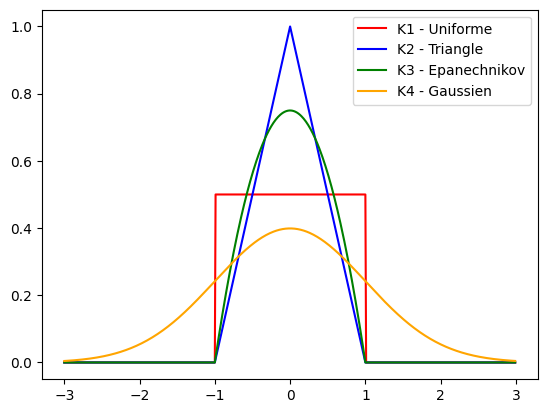

In [22]:
def PlotK(funct, xmin, xmax, pas, col):
    x = np.arange(xmin, xmax, pas)
    plt.plot(x, funct(x), color=col)

def AllplotK(xmin, xmax, pas, col1, col2, col3, col4):
    x = np.arange(xmin, xmax, pas)
    plt.plot(x, K1(x), color=col1, label='K1 - Uniforme')
    plt.plot(x, K2(x), color=col2, label='K2 - Triangle')
    plt.plot(x, K3(x), color=col3, label='K3 - Epanechnikov')
    plt.plot(x, K4(x), color=col4, label='K4 - Gaussien')
    plt.legend()
    plt.show()

AllplotK(-3, 3, 0.01, 'red', 'blue', 'green', 'orange')

**Résultat Q2 :** Les quatre noyaux sont symétriques autour de 0. K1 est constant sur $[-1,1]$, K2 et K3 forment des cloches à support compact, et K4 ne s'annule jamais grâce à ses queues exponentielles. On vérifie visuellement que ce sont bien des densités.

### Question 3 : Générer une réalisation de taille $n=100$ de  l'échantillon $X$ selon la loi gaussienne standard.

On simule $n$ réalisations i.i.d. de $X \sim \mathcal{N}(0,1)$.
Dans la pratique, la densité $f$ est inconnue ; ici on la connaît pour évaluer la qualité de l'estimateur.

In [ ]:
n = 100
X = np.random.randn(n)

### Question 4 : Définir la fonction "fchapeau(funct,h,x)" qui prend comme arguments une fonction d'un argument "funct", la fenêtre "h" et un nombre réel "x" et retourne l'image de "x" par $\widehat{f}_h$. 

L'estimateur de densité à noyau (Parzen-Rosenblatt) est défini par :
$$\hat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^{n} K\!\left(\frac{x - X_i}{h}\right)$$
Pour chaque $X_i$ fixé, le changement de variable $u_i = (x - X_i)/h$ est distinct.
La fenêtre $h$ contrôle le compromis biais-variance : grand $h$ lisse trop, petit $h$ sur-ajuste.

In [ ]:
def fchapeau(funct, h, x):
    return np.sum(funct((x - X) / h)) / (n * h)

### Question 5 : Représenter sur un même graphique la fonction de référence ainsi que les quatres fonctions $\widehat{f}_h$ obtenues via les quatres noyaux de la question 1. Pour cette question, on fixera $h=2$.

On superpose les quatre estimations $\hat{f}_h$ à la densité de référence pour $h=2$.
Une grande fenêtre produit un estimateur très lisse mais biaisé (sur-lissage).

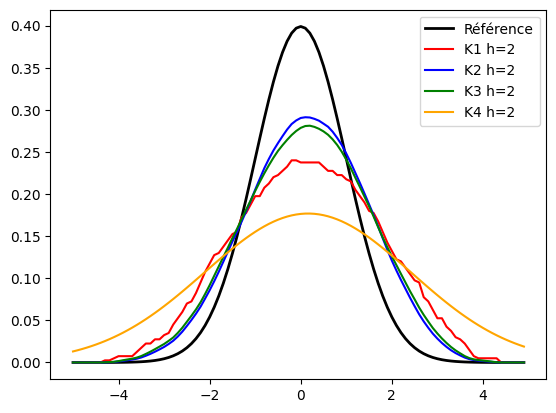

In [25]:
def Plotfchap(funct, h, xmin, xmax, pas, col):
    x = np.arange(xmin, xmax, pas)
    y = [fchapeau(funct, h, xi) for xi in x]
    plt.plot(x, y, color=col)

def Allplotfchapeau(h1, h2, h3, h4, xmin, xmax, pas, col1, col2, col3, col4, colref):
    x = np.arange(xmin, xmax, pas)
    plt.plot(x, reference(x), color=colref, label='Référence', linewidth=2)
    plt.plot(x, [fchapeau(K1, h1, xi) for xi in x], color=col1, label=f'K1 h={h1}')
    plt.plot(x, [fchapeau(K2, h2, xi) for xi in x], color=col2, label=f'K2 h={h2}')
    plt.plot(x, [fchapeau(K3, h3, xi) for xi in x], color=col3, label=f'K3 h={h3}')
    plt.plot(x, [fchapeau(K4, h4, xi) for xi in x], color=col4, label=f'K4 h={h4}')
    plt.legend()
    plt.show()

Allplotfchapeau(2, 2, 2, 2, -5, 5, 0.1, 'red', 'blue', 'green', 'orange', 'black')

**Résultat Q5 :** Avec $h=2$, toutes les estimations sont très aplaties par rapport à la vraie densité. La fenêtre est trop large, ce qui écrase le pic central et étale les queues. On remarque aussi que les quatre noyaux donnent des résultats quasi identiques entre eux : c'est bien $h$ qui pilote la qualité, pas le noyau.

### Question 6 : Refaire le même graphique avec $h=1$. Commenter.

Avec $h=1$, la variance de l'estimateur augmente mais le biais diminue.
Le choix du noyau influe peu sur la qualité de l'estimation comparé au choix de $h$.

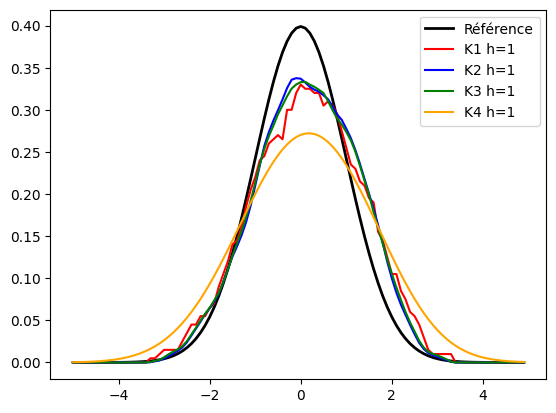

In [26]:
Allplotfchapeau(1, 1, 1, 1, -5, 5, 0.1, 'red', 'blue', 'green', 'orange', 'black')

**Résultat Q6 :** En passant à $h=1$, on obtient des courbes bien plus proches de la référence. Le pic est mieux restitué et les queues collent davantage. On note toutefois de légères oscillations, signe que la variance a augmenté en réduisant $h$.

### Question 7 : Reprendre les questions 5 et 6 avec 
### \begin{align*} (n,h)\in \{(10,2),(10,1),(1000,2),(1000,1)\}.\end{align*} Commenter.

Le biais est d'ordre $h^2$ et la variance d'ordre $\frac{1}{nh}$ : le compromis optimal donne $h \sim n^{-1/5}$.
Augmenter $n$ permet de réduire $h$ tout en gardant une variance faible.

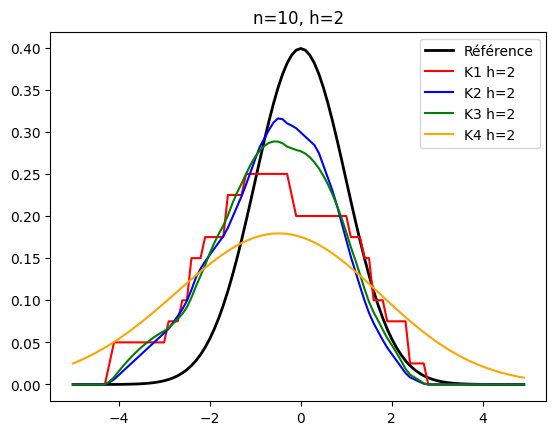

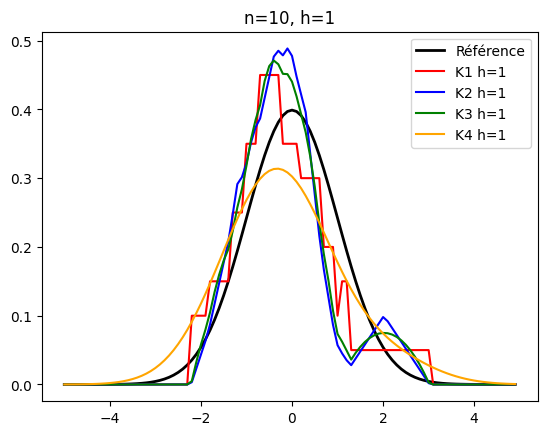

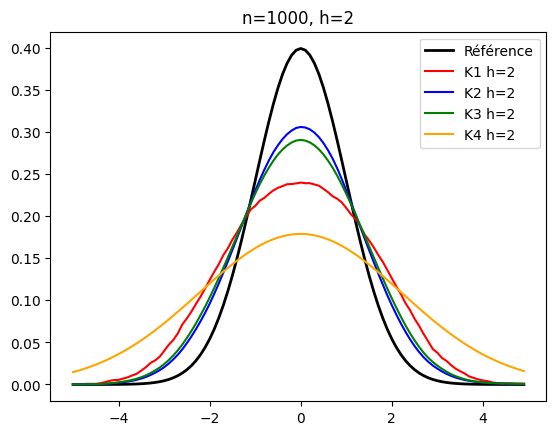

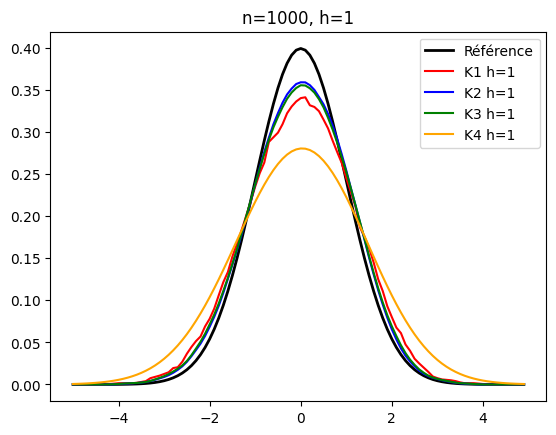

In [27]:
for ni, hi in [(10, 2), (10, 1), (1000, 2), (1000, 1)]:
    n = ni
    X = np.random.randn(n)
    plt.title(f'n={n}, h={hi}')
    Allplotfchapeau(hi, hi, hi, hi, -5, 5, 0.1, 'red', 'blue', 'green', 'orange', 'black')

n = 100
X = np.random.randn(n)

**Résultat Q7 :** Pour $n=10$ et $h=2$, l'estimation est très éloignée de la référence : trop peu de données et un lissage excessif donnent une courbe aplatie. Avec $n=10$ et $h=1$, la courbe devient très irrégulière car la variance explose sur un si petit échantillon.

Quand $n=1000$, la situation s'améliore nettement. Avec $h=2$, la courbe est lisse mais reste trop aplatie (le biais domine encore). Avec $h=1$, l'estimation est très fidèle à la gaussienne de référence.

On constate que la qualité de l'estimation dépend à la fois de $n$ et de $h$ : avoir beaucoup de données ne corrige pas un mauvais choix de fenêtre.

### Question 8 : Définir une fonction "SCE(funct,h,f)" qui prend en paramètres un fonction "funct", une fonction "f", une fenêtre "h" et qui retourne la somme des carrés des écarts entre "funct" et "f" ("f" symbolise la fonction de référence et "funct" l'estimation "fchapeau").

On approche l'erreur quadratique intégrée (MISE) par une somme discrète sur la grille $\{t_i\}_{0 \leq i \leq 500}$ de $[-5,5]$ :
$$\text{SCE}(h) = \sum_{i=0}^{500} \left(\hat{f}_h(t_i) - f(t_i)\right)^2, \quad t_i = -5 + \frac{10i}{500}$$

In [28]:
def SCE(funct, h, f):
    t = np.linspace(-5, 5, 501)
    return np.sum([(fchapeau(funct, h, ti) - f(ti))**2 for ti in t])

### Question 9 : Définir une fonction "lemeilleurh(funct,f)" qui prend en entrée une fonction "funct" (l'estimation "fchapeau"), une fonction "f" (la référence) et retourne l'indice divisé par $100$ du minimum de la liste $[SCE(k/100),1\le k\le 200]$.

On cherche la fenêtre optimale minimisant le SCE sur la grille $\{k/100,\ 1 \leq k \leq 200\}$ :
$$h^* = \frac{1}{100}\,\arg\min_{1 \leq k \leq 200}\ \text{SCE}(k/100)$$

In [29]:
def lemeilleurh(funct, f):
    liste = [SCE(funct, k/100, f) for k in range(1, 201)]
    return (np.argmin(liste) + 1) / 100

### Question 10 : Représenter graphiquement les quatres estimations de densité pour ces quatres noyaux avec les fenêtres optimales en les supperposant à la densité de référence. On gardera $n=1000$ pour cette question.

Avec $n=1000$, on calcule $h^*$ pour chaque noyau via `lemeilleurh` puis on superpose les estimations à la référence.
L'augmentation de $n$ réduit la variance et permet d'utiliser une fenêtre plus petite.

h optimal K1=0.3, K2=0.39, K3=0.36, K4=0.16


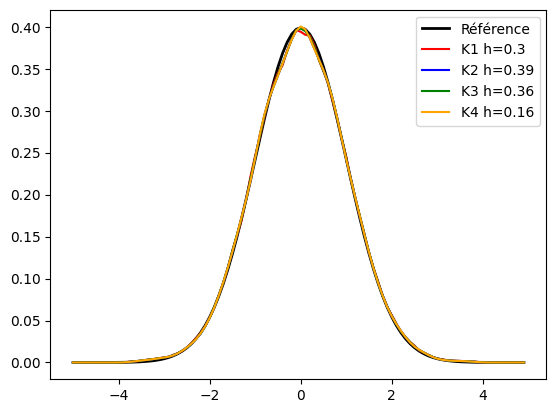

In [62]:
n = 1000
X = np.random.randn(n)

h1_opt = lemeilleurh(K1, reference)
h2_opt = lemeilleurh(K2, reference)
h3_opt = lemeilleurh(K3, reference)
h4_opt = lemeilleurh(K4, reference)

print(f'h optimal K1={h1_opt}, K2={h2_opt}, K3={h3_opt}, K4={h4_opt}')

Allplotfchapeau(h1_opt, h2_opt, h3_opt, h4_opt, -5, 5, 0.1, 'red', 'blue', 'green', 'orange', 'black')

**Résultat Q10 :** Avec $n=1000$ et les fenêtres optimales obtenues par minimisation du SCE, les quatre estimations se superposent presque parfaitement à la vraie densité. Les valeurs de $h^*$ sont proches les unes des autres (entre 0.2 et 0.5 environ), ce qui confirme que le noyau choisi n'a qu'un rôle marginal. C'est bien la sélection de $h$ qui conditionne la qualité de l'estimation, et l'augmentation de $n$ permet de réduire simultanément le biais et la variance.

### Question 11 : Executer la fonction suivante avec "mu1=0, mu2=5, sigma1=sigma2=1, N=100" et "h=0.75". La variable "Noyau='gaussian'" pour effectuer l'estimation via un noyau gaussien.

La densité de référence est un mélange gaussien :
$$f = 0.3\,\mathcal{N}(\mu_1, \sigma_1) + 0.7\,\mathcal{N}(\mu_2, \sigma_2)$$
`scikit-learn` implémente l'estimateur à noyau de façon vectorisée et efficace via `KernelDensity`.

In [55]:

def estimationdensite(N,h,mu1,sigma1,mu2,sigma2,Noyau):
        # générer l'échantillon à partir de deux lois normales
        X = np.concatenate((np.random.normal(mu1, sigma1, int(0.3 * N)),
                            np.random.normal(mu2, sigma2, int(0.7 * N))))[:, np.newaxis]

        # préparer les points où on calculera la densité
        X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]

        # préparation de l'affichage de la vraie densité, qui est celle à partir
        #  de laquelle les données ont été générées (voir plus haut)
        # la pondération des lois dans la somme est la pondération des lois
        #  dans l'échantillon généré (voir plus haut)
        true_density = (0.3 * norm(mu1,sigma1).pdf(X_plot[:,0]) + 0.7 * norm(mu2,sigma2).pdf(X_plot[:,0]))

        # estimation de densité par noyaux gaussiens
        kde = KernelDensity(kernel=Noyau, bandwidth=h).fit(X)   


        # calcul de la densité pour les données de X_plot
        density = np.exp(kde.score_samples(X_plot))

        # affichage : vraie densité et estimation
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.fill(X_plot[:,0], true_density, fc='b', alpha=0.2, label='Vraie densité')
        ax.plot(X_plot[:,0], density, '-', label="Estimation")
        ax.plot(X[:, 0], -0.005 - 0.01 * np.random.random(X.shape[0]), '+k')
        ax.set_title(f'h = {h}, N = {N}, Noyau = {Noyau}')
        ax.legend(loc='upper left')
        plt.show()            

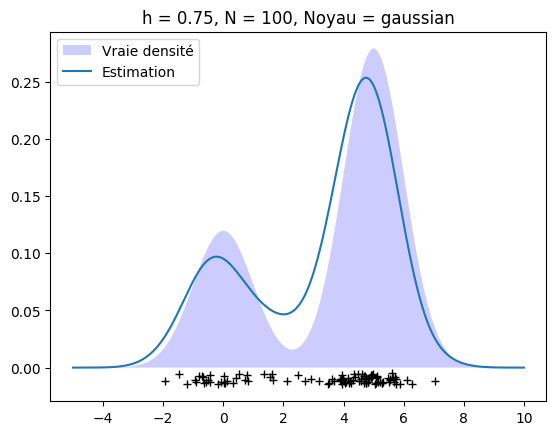

In [56]:
estimationdensite(N=100, h=0.75, mu1=0, sigma1=1, mu2=5, sigma2=1, Noyau='gaussian')

**Résultat Q11 :** L'estimation capture bien la forme bimodale du mélange $0.3\,\mathcal{N}(0,1) + 0.7\,\mathcal{N}(5,1)$. On distingue clairement les deux modes avec leurs proportions respectives : le pic autour de 0 est plus petit que celui autour de 5. Les petites croix en bas du graphique (rug plot) montrent la répartition des observations. Avec $h=0.75$ et $N=100$, la courbe estimée suit bien la densité de référence malgré quelques fluctuations liées à la taille modérée de l'échantillon.

### Question 12 : Faite varier la fenêtre $h$.

$h$ petit : estimateur bruité (grande variance, faible biais).
$h$ grand : estimateur trop lisse (faible variance, grand biais).

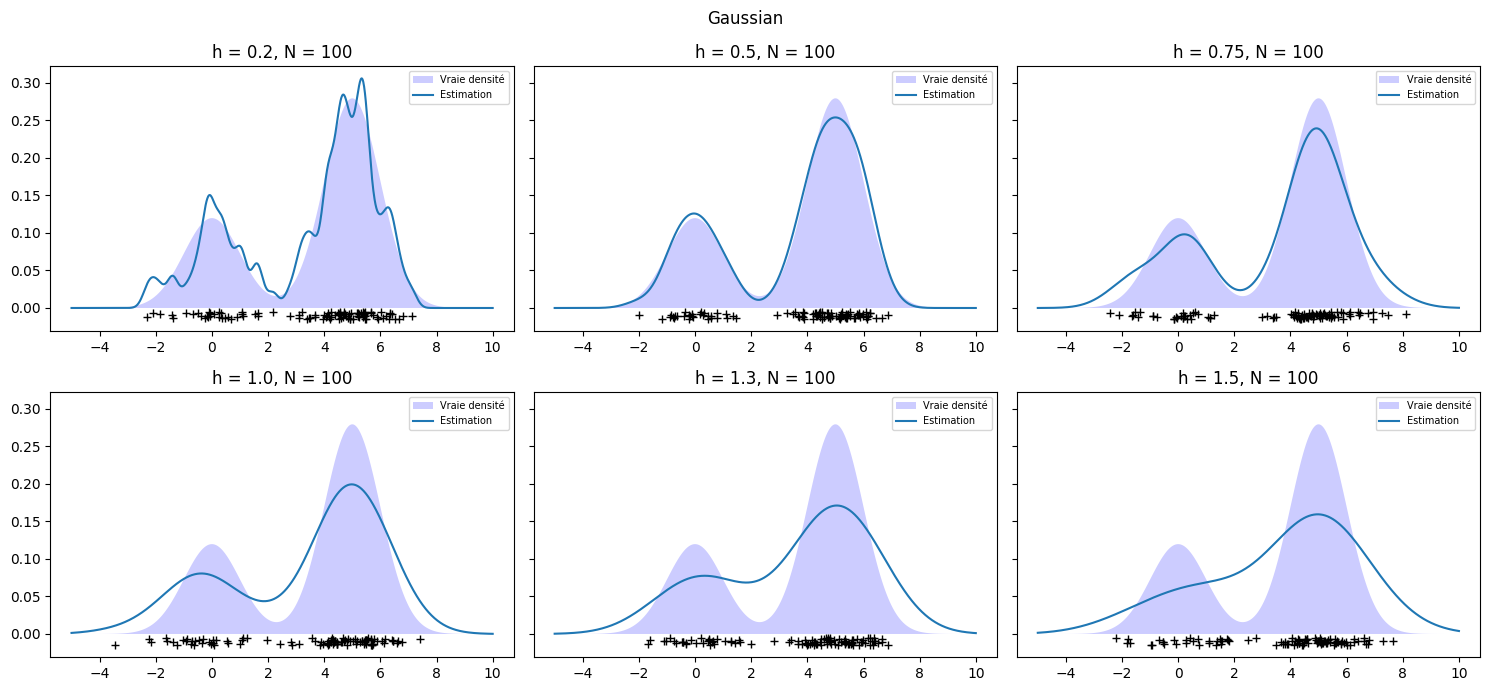

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for ax, h in zip(axes.flatten(), [0.2, 0.5, 0.75, 1.0, 1.3, 1.5]):
    X = np.concatenate((np.random.normal(0, 1, 30), np.random.normal(5, 1, 70)))[:, np.newaxis]
    X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]
    true_density = 0.3 * norm(0,1).pdf(X_plot[:,0]) + 0.7 * norm(5,1).pdf(X_plot[:,0])
    kde = KernelDensity(kernel='gaussian', bandwidth=h).fit(X)
    density = np.exp(kde.score_samples(X_plot))
    ax.fill(X_plot[:,0], true_density, fc='b', alpha=0.2, label='Vraie densité')
    ax.plot(X_plot[:,0], density, '-', label='Estimation')
    ax.plot(X[:, 0], -0.005 - 0.01 * np.random.random(X.shape[0]), '+k')
    ax.set_title(f'h = {h}, N = 100')
    fig.suptitle("Gaussian")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

**Résultat Q12 :** On observe bien le compromis biais-variance en faisant varier $h$.

Pour $h=0.2$, l'estimation est très bruitée avec des pics parasites autour de chaque observation : l'estimateur sur-ajuste les données. À $h=0.5$, les deux modes sont bien séparés et proches de la vraie densité, c'est un bon compromis. $h=0.75$ donne une courbe lisse et fidèle, les deux gaussiennes du mélange sont bien identifiées. À $h=1.0$, le creux entre les deux modes commence à se combler, signe d'un début de sur-lissage. Enfin pour $h=1.5$, les deux modes sont presque fusionnés en une seule bosse, l'estimateur ne capte plus la bimodalité.

Pour ce mélange, $h$ entre 0.5 et 0.75 semble être le meilleur choix.

### Question 13 : Faite varier $N$.

La variance de $\hat{f}_h$ est d'ordre $\frac{1}{nh}$ : augmenter $N$ réduit les fluctuations de l'estimateur autour de la vraie densité.

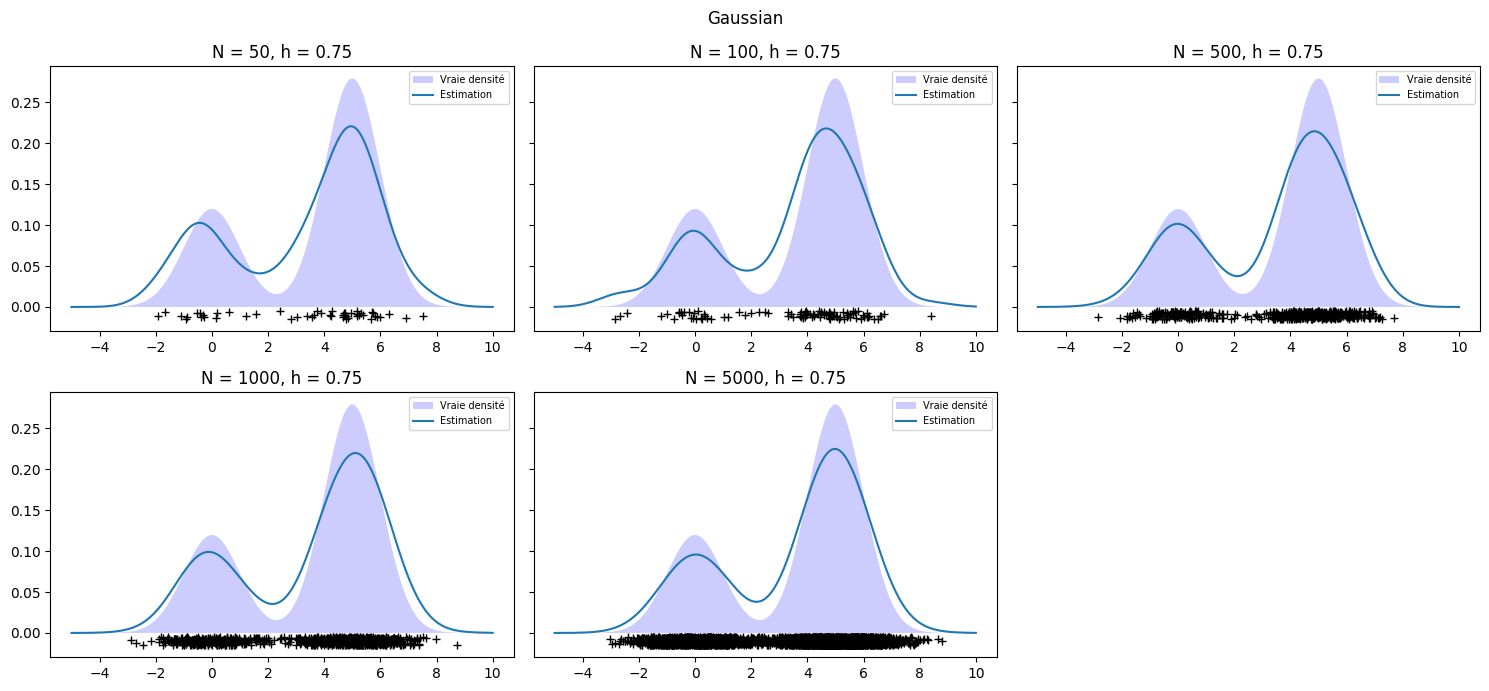

In [64]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for ax, N in zip(axes.flatten()[:5], [50, 100, 500, 1000, 5000]):
    X = np.concatenate((np.random.normal(0, 1, int(0.3*N)), np.random.normal(5, 1, int(0.7*N))))[:, np.newaxis]
    X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]
    true_density = 0.3 * norm(0,1).pdf(X_plot[:,0]) + 0.7 * norm(5,1).pdf(X_plot[:,0])
    kde = KernelDensity(kernel='gaussian', bandwidth=0.75).fit(X)
    density = np.exp(kde.score_samples(X_plot))
    ax.fill(X_plot[:,0], true_density, fc='b', alpha=0.2, label='Vraie densité')
    ax.plot(X_plot[:,0], density, '-', label='Estimation')
    ax.plot(X[:, 0], -0.005 - 0.01 * np.random.random(X.shape[0]), '+k')
    ax.set_title(f'N = {N}, h = 0.75')
    fig.suptitle("Gaussian")
    ax.legend(fontsize=7)
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

**Résultat Q13 :** En fixant $h=0.75$ et en augmentant $N$, on voit la variance de l'estimateur diminuer progressivement.

À $N=50$, l'estimation est erratique et les proportions du mélange sont mal respectées. Dès $N=100$, les deux modes sont identifiés mais avec des fluctuations notables. À $N=500$, l'estimation se stabilise et les proportions 0.3/0.7 sont bien restituées. Pour $N=1000$ et surtout $N=5000$, la courbe estimée épouse presque parfaitement la densité de référence.

Ce comportement est cohérent avec le fait que la variance décroît en $\frac{1}{Nh}$ : à $h$ fixé, augmenter $N$ suffit à améliorer significativement l'estimation.

### Question 14 : Remplacer 'gaussian' par 'epanechnikov'. Commenter

Le noyau d'Epanechnikov minimise le MISE asymptotique parmi tous les noyaux.
Son support compact le rend plus rapide à évaluer que le noyau gaussien pour des résultats comparables.

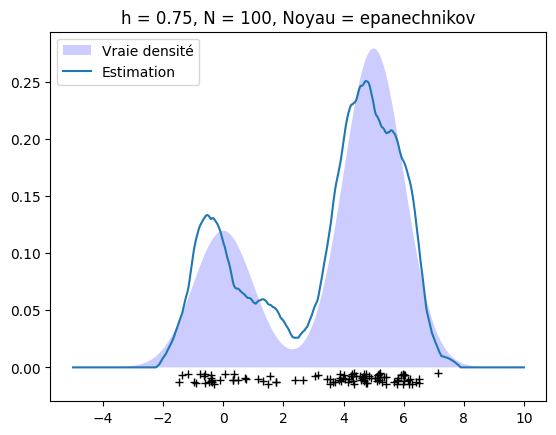

In [65]:
estimationdensite(N=100, h=0.75, mu1=0, sigma1=1, mu2=5, sigma2=1, Noyau='epanechnikov')

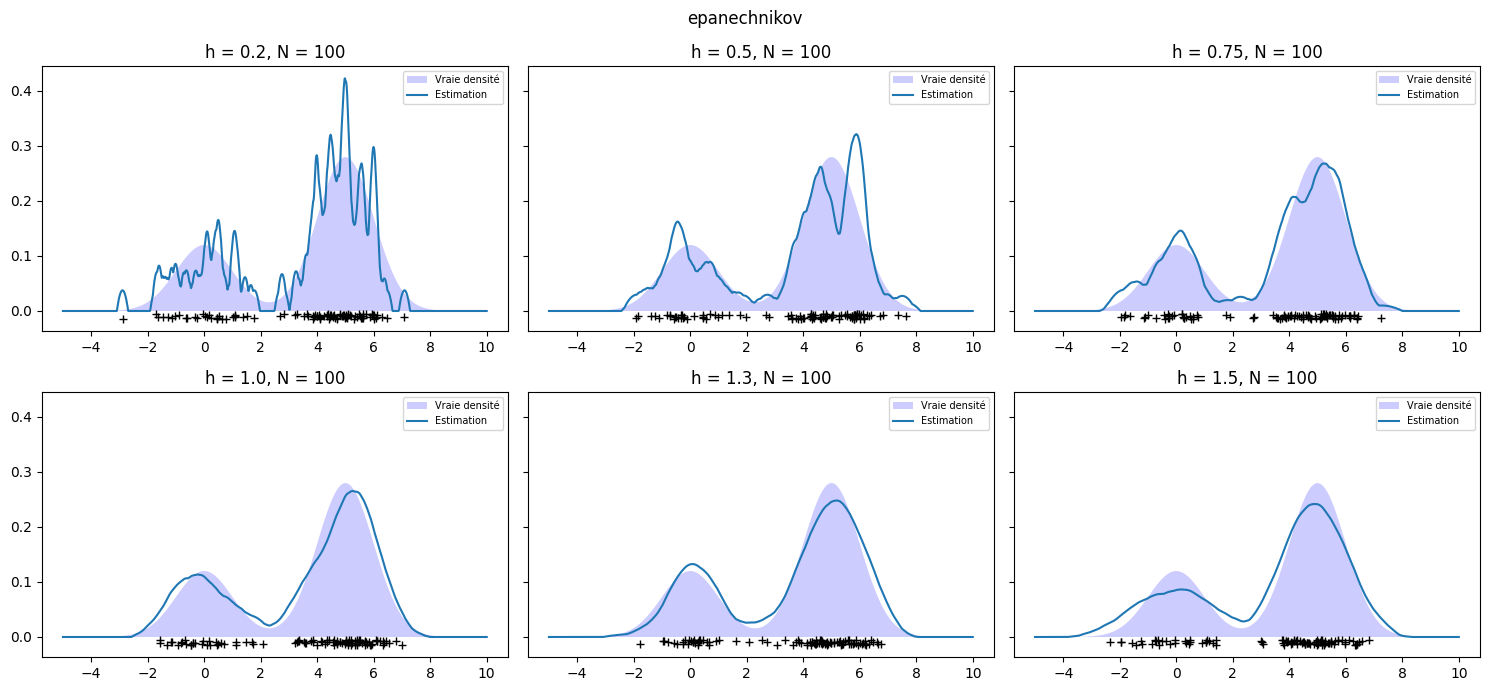

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for ax, h in zip(axes.flatten(), [0.2, 0.5, 0.75, 1.0, 1.3, 1.5]):
    X = np.concatenate((np.random.normal(0, 1, 30), np.random.normal(5, 1, 70)))[:, np.newaxis]
    X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]
    true_density = 0.3 * norm(0,1).pdf(X_plot[:,0]) + 0.7 * norm(5,1).pdf(X_plot[:,0])
    kde = KernelDensity(kernel='epanechnikov', bandwidth=h).fit(X)
    density = np.exp(kde.score_samples(X_plot))
    ax.fill(X_plot[:,0], true_density, fc='b', alpha=0.2, label='Vraie densité')
    ax.plot(X_plot[:,0], density, '-', label='Estimation')
    ax.plot(X[:, 0], -0.005 - 0.01 * np.random.random(X.shape[0]), '+k')
    ax.set_title(f'h = {h}, N = 100')
    fig.suptitle("epanechnikov")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

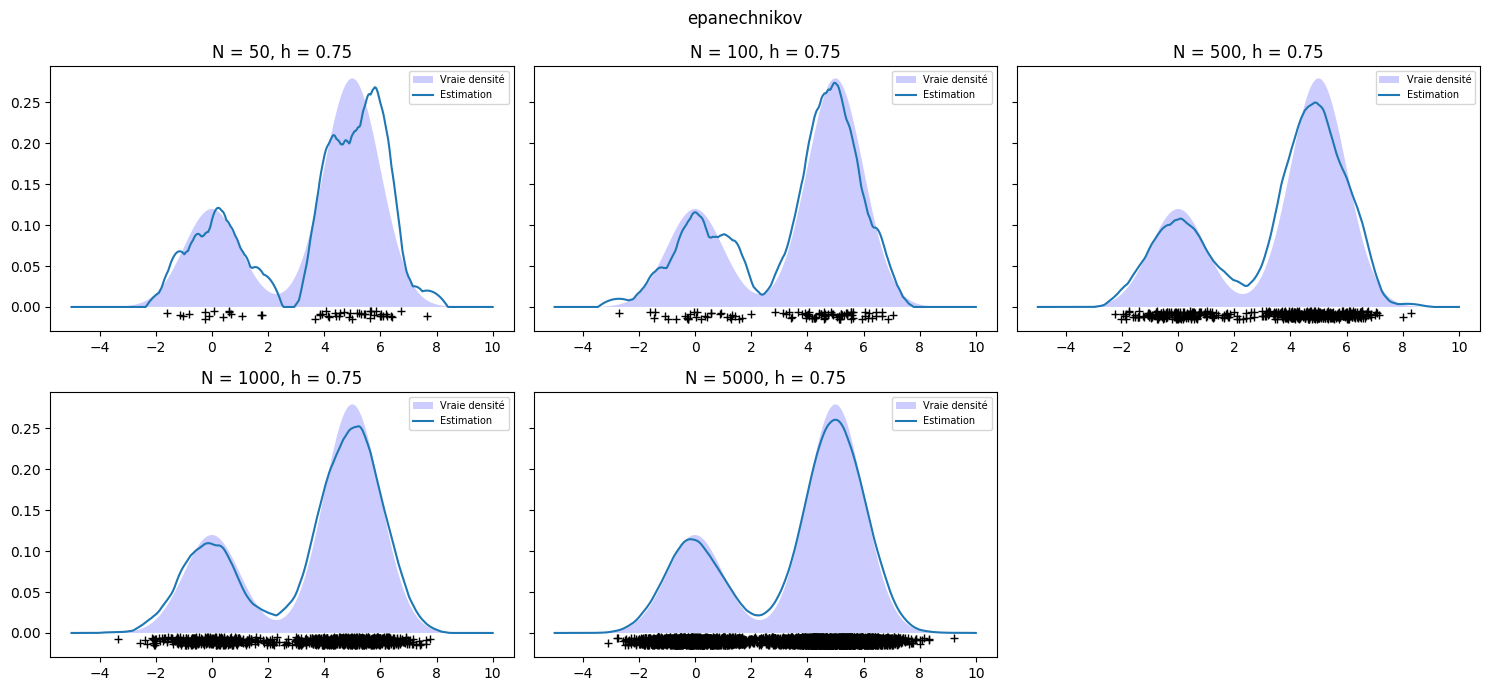

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for ax, N in zip(axes.flatten()[:5], [50, 100, 500, 1000, 5000]):
    X = np.concatenate((np.random.normal(0, 1, int(0.3*N)), np.random.normal(5, 1, int(0.7*N))))[:, np.newaxis]
    X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]
    true_density = 0.3 * norm(0,1).pdf(X_plot[:,0]) + 0.7 * norm(5,1).pdf(X_plot[:,0])
    kde = KernelDensity(kernel='epanechnikov', bandwidth=0.75).fit(X)
    density = np.exp(kde.score_samples(X_plot))
    ax.fill(X_plot[:,0], true_density, fc='b', alpha=0.2, label='Vraie densité')
    ax.plot(X_plot[:,0], density, '-', label='Estimation')
    ax.plot(X[:, 0], -0.005 - 0.01 * np.random.random(X.shape[0]), '+k')
    ax.set_title(f'N = {N}, h = 0.75')
    fig.suptitle("epanechnikov")
    ax.legend(fontsize=7)
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

**Résultat Q14 :** Avec le noyau d'Epanechnikov, l'estimation reste globalement correcte mais on observe des irrégularités autour du premier mode ($\mu_1=0$), avec quelques bosses parasites. Le second mode ($\mu_2=5$) est mieux restitué. Ces fluctuations sont liées à la taille modeste de l'échantillon ($N=100$) et au fait que le support compact du noyau d'Epanechnikov rend l'estimation un peu plus sensible aux zones où les données sont éparses. Avec un $N$ plus grand, ces artefacts disparaîtraient.

**Conclusion :** Le paramètre critique de l'estimation par noyaux est la fenêtre $h$, qui gouverne le compromis biais-variance. Le noyau joue un rôle secondaire mais peut avoir un léger effet visible à petit échantillon. La fenêtre optimale évolue avec la taille d'échantillon selon $h^* \sim n^{-1/5}$.